# Symptom-Based Disease Prediction — Model Training Notebook

**Pipeline:** EDA → Preprocessing → Feature Engineering → Model Selection → Hyperparameter Tuning → Evaluation → Prediction Demo

Dataset: `dataset.csv`, `symptom_Description.csv`, `symptom_precaution.csv`, `Symptom-severity.csv`


## 1. Imports & Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import json
import re
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.naive_bayes import BernoulliNB
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              classification_report, confusion_matrix)

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

RANDOM_STATE = 42
DATA_DIR = 'data'


## 2. Load Data

In [2]:
df = pd.read_csv(f'{DATA_DIR}/dataset.csv')
desc_df = pd.read_csv(f'{DATA_DIR}/symptom_Description.csv')
precaution_df = pd.read_csv(f'{DATA_DIR}/symptom_precaution.csv')
severity_df = pd.read_csv(f'{DATA_DIR}/Symptom-severity.csv')

print("Main dataset shape:", df.shape)
print("Diseases:", df['Disease'].nunique())
df.head()


Main dataset shape: (4920, 18)
Diseases: 41


,Disease,Symptom_1,Symptom_2,Symptom_3,Symptom_4,Symptom_5,Symptom_6,Symptom_7,Symptom_8,Symptom_9,Symptom_10,Symptom_11,Symptom_12,Symptom_13,Symptom_14,Symptom_15,Symptom_16,Symptom_17
0,Fungal infection,itching,skin_rash,nodal_skin_eruptions,dischromic _patches,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Fungal infection,skin_rash,nodal_skin_eruptions,dischromic _patches,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Fungal infection,itching,nodal_skin_eruptions,dischromic _patches,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Fungal infection,itching,skin_rash,dischromic _patches,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Fungal infection,itching,skin_rash,nodal_skin_eruptions,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 3. Exploratory Data Analysis (EDA)

Check class balance, missing values, and how many symptoms are typically recorded per case.

Number of unique diseases: 41

Min/Max samples per disease: 120 / 120


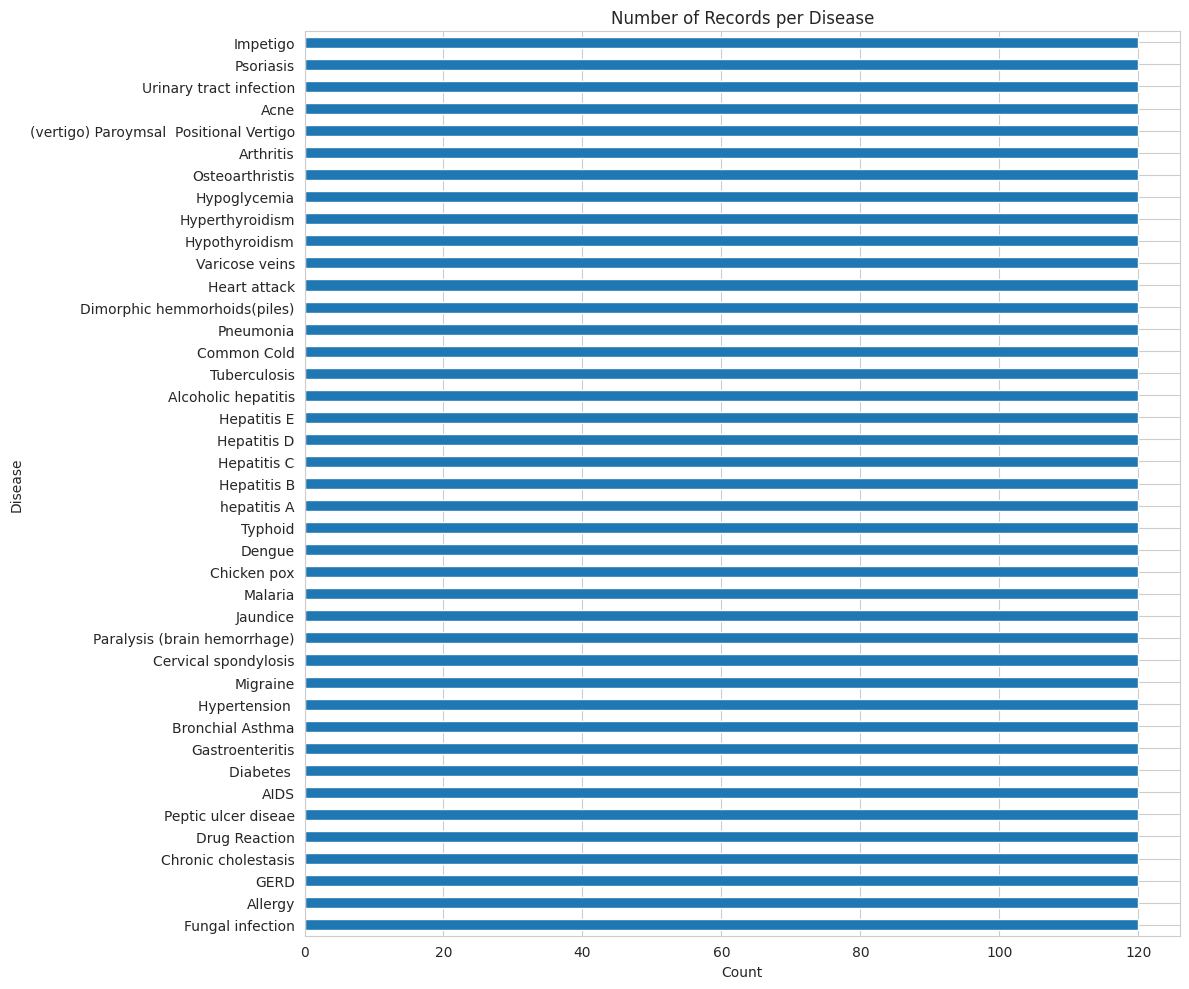

In [3]:
# Class balance
disease_counts = df['Disease'].value_counts()
print("Number of unique diseases:", disease_counts.shape[0])
print("\nMin/Max samples per disease:", disease_counts.min(), "/", disease_counts.max())

plt.figure(figsize=(12, 10))
disease_counts.sort_values().plot(kind='barh')
plt.title('Number of Records per Disease')
plt.xlabel('Count')
plt.tight_layout()
plt.show()


In [4]:
# Missing values per symptom column (NaN = no symptom recorded in that slot, expected)
symptom_cols = [c for c in df.columns if c.startswith('Symptom_')]
missing_pct = df[symptom_cols].isna().mean() * 100
print(missing_pct)


Symptom_1      0.000000
Symptom_2      0.000000
Symptom_3      0.000000
Symptom_4      7.073171
Symptom_5     24.512195
Symptom_6     40.365854
Symptom_7     53.902439
Symptom_8     60.487805
Symptom_9     65.609756
Symptom_10    69.268293
Symptom_11    75.731707
Symptom_12    84.878049
Symptom_13    89.756098
Symptom_14    93.780488
Symptom_15    95.121951
Symptom_16    96.097561
Symptom_17    98.536585
dtype: float64


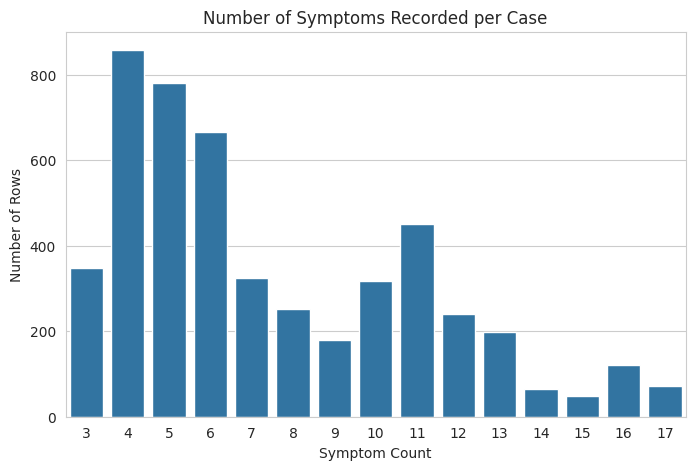

count    4920.000000
mean        7.448780
std         3.592166
min         3.000000
25%         5.000000
50%         6.000000
75%        10.000000
max        17.000000
dtype: float64


In [5]:
# How many symptoms are recorded per case (row)?
symptoms_per_row = df[symptom_cols].notna().sum(axis=1)
plt.figure(figsize=(8, 5))
sns.countplot(x=symptoms_per_row)
plt.title('Number of Symptoms Recorded per Case')
plt.xlabel('Symptom Count')
plt.ylabel('Number of Rows')
plt.show()

print(symptoms_per_row.describe())


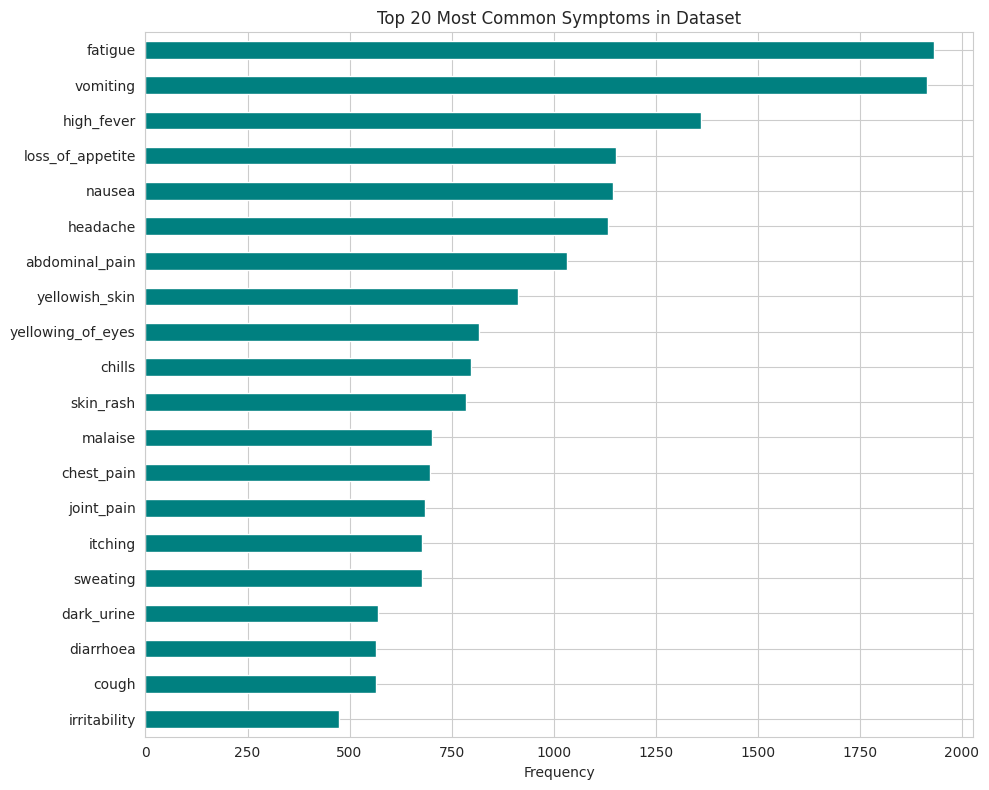

In [6]:
# Most frequent individual symptoms across the whole dataset
all_symptoms_raw = df[symptom_cols].values.flatten()
all_symptoms_clean = pd.Series([str(s).strip().lower() for s in all_symptoms_raw if pd.notna(s)])
top_symptoms = all_symptoms_clean.value_counts().head(20)

plt.figure(figsize=(10, 8))
top_symptoms.sort_values().plot(kind='barh', color='teal')
plt.title('Top 20 Most Common Symptoms in Dataset')
plt.xlabel('Frequency')
plt.tight_layout()
plt.show()


## 4. Data Preprocessing

- Strip whitespace and lowercase all symptom text (the raw CSV has inconsistent leading spaces like `' skin_rash'`)
- Treat NaN symptom slots as "not present"
- Build a clean master list of all unique symptoms


In [7]:
def clean_symptom(s):
    if pd.isna(s):
        return None
    return str(s).strip().lower().replace(' ', '_')

# Clean every symptom cell
df_clean = df.copy()
for col in symptom_cols:
    df_clean[col] = df_clean[col].apply(clean_symptom)

# Build the master vocabulary of unique symptoms
all_symptoms = set()
for col in symptom_cols:
    all_symptoms.update(df_clean[col].dropna().unique())
all_symptoms = sorted(all_symptoms)

print(f"Total unique symptoms in vocabulary: {len(all_symptoms)}")
print(all_symptoms[:15], '...')


Total unique symptoms in vocabulary: 131
['abdominal_pain', 'abnormal_menstruation', 'acidity', 'acute_liver_failure', 'altered_sensorium', 'anxiety', 'back_pain', 'belly_pain', 'blackheads', 'bladder_discomfort', 'blister', 'blood_in_sputum', 'bloody_stool', 'blurred_and_distorted_vision', 'breathlessness'] ...


## 5. Feature Engineering

Convert each row's list of symptoms into a binary (one-hot) feature vector — one column per unique symptom, 1 if present in that case, 0 if not. This is the standard representation for this kind of tabular symptom-checklist data.


In [8]:
# Build binary symptom matrix
feature_rows = []
for _, row in df_clean.iterrows():
    present = set(row[symptom_cols].dropna())
    feature_rows.append({sym: 1 if sym in present else 0 for sym in all_symptoms})

X = pd.DataFrame(feature_rows, columns=all_symptoms)
y_raw = df_clean['Disease'].str.strip()

print("Feature matrix shape:", X.shape)
X.head()


Feature matrix shape: (4920, 131)


,abdominal_pain,abnormal_menstruation,acidity,acute_liver_failure,altered_sensorium,anxiety,back_pain,belly_pain,blackheads,bladder_discomfort,...,vomiting,watering_from_eyes,weakness_in_limbs,weakness_of_one_body_side,weight_gain,weight_loss,yellow_crust_ooze,yellow_urine,yellowing_of_eyes,yellowish_skin
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [9]:
# Encode target labels
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y_raw)

print("Number of classes:", len(label_encoder.classes_))
print(dict(list(zip(label_encoder.classes_, range(len(label_encoder.classes_))))[:5]), '...')


Number of classes: 41
{'(vertigo) Paroymsal  Positional Vertigo': 0, 'AIDS': 1, 'Acne': 2, 'Alcoholic hepatitis': 3, 'Allergy': 4} ...


In [10]:
# Merge description + precaution info into a single lookup dict, keyed by disease name
desc_df['Disease'] = desc_df['Disease'].str.strip()
precaution_df['Disease'] = precaution_df['Disease'].str.strip()

disease_info = {}
for disease in label_encoder.classes_:
    desc_row = desc_df[desc_df['Disease'] == disease]
    prec_row = precaution_df[precaution_df['Disease'] == disease]

    description = desc_row['Description'].values[0] if len(desc_row) else "No description available."
    precaution_cols = [c for c in precaution_df.columns if c.startswith('Precaution')]
    precautions = []
    if len(prec_row):
        precautions = [p for p in prec_row[precaution_cols].values[0] if pd.notna(p) and str(p).strip() != '']

    disease_info[disease] = {
        'description': description,
        'precautions': precautions
    }

with open('disease_info.json', 'w') as f:
    json.dump(disease_info, f, indent=2)

print("Sample entry:")
print(json.dumps(disease_info['Malaria'], indent=2))


Sample entry:
{
  "description": "An infectious disease caused by protozoan parasites from the Plasmodium family that can be transmitted by the bite of the Anopheles mosquito or by a contaminated needle or transfusion. Falciparum malaria is the most deadly type.",
  "precautions": [
    "Consult nearest hospital",
    "avoid oily food",
    "avoid non veg food",
    "keep mosquitos out"
  ]
}


## 6. Train / Test Split

Stratified split so every disease is proportionally represented in both sets.

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)


Train shape: (3936, 131)
Test shape: (984, 131)


## 7. Model Selection

Train multiple candidate algorithms and compare them on accuracy, precision, recall, and F1 (all weighted-average, since we have 41 balanced classes) using both a held-out test set and cross-validation on the training set.


In [12]:
candidate_models = {
    'Decision Tree': DecisionTreeClassifier(random_state=RANDOM_STATE),
    'Random Forest': RandomForestClassifier(random_state=RANDOM_STATE, n_estimators=200),
    'Naive Bayes (Bernoulli)': BernoulliNB(),
    'SVM (linear)': SVC(kernel='linear', probability=True, random_state=RANDOM_STATE),
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    'Gradient Boosting': GradientBoostingClassifier(random_state=RANDOM_STATE),
}

results = []
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

for name, model in candidate_models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    acc = accuracy_score(y_test, preds)
    prec = precision_score(y_test, preds, average='weighted', zero_division=0)
    rec = recall_score(y_test, preds, average='weighted', zero_division=0)
    f1 = f1_score(y_test, preds, average='weighted', zero_division=0)
    cv_scores = cross_val_score(model, X_train, y_train, cv=skf, scoring='accuracy')

    results.append({
        'Model': name,
        'Test Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1 Score': f1,
        'CV Mean Accuracy': cv_scores.mean(),
        'CV Std': cv_scores.std()
    })
    print(f"{name:28s} | Acc: {acc:.4f} | Prec: {prec:.4f} | Rec: {rec:.4f} | F1: {f1:.4f} | CV: {cv_scores.mean():.4f} (+/-{cv_scores.std():.4f})")

results_df = pd.DataFrame(results).sort_values('Test Accuracy', ascending=False).reset_index(drop=True)
results_df


Decision Tree                | Acc: 1.0000 | Prec: 1.0000 | Rec: 1.0000 | F1: 1.0000 | CV: 1.0000 (+/-0.0000)


Random Forest                | Acc: 1.0000 | Prec: 1.0000 | Rec: 1.0000 | F1: 1.0000 | CV: 1.0000 (+/-0.0000)
Naive Bayes (Bernoulli)      | Acc: 1.0000 | Prec: 1.0000 | Rec: 1.0000 | F1: 1.0000 | CV: 1.0000 (+/-0.0000)


SVM (linear)                 | Acc: 1.0000 | Prec: 1.0000 | Rec: 1.0000 | F1: 1.0000 | CV: 1.0000 (+/-0.0000)


KNN                          | Acc: 1.0000 | Prec: 1.0000 | Rec: 1.0000 | F1: 1.0000 | CV: 1.0000 (+/-0.0000)


Logistic Regression          | Acc: 1.0000 | Prec: 1.0000 | Rec: 1.0000 | F1: 1.0000 | CV: 1.0000 (+/-0.0000)


Gradient Boosting            | Acc: 1.0000 | Prec: 1.0000 | Rec: 1.0000 | F1: 1.0000 | CV: 0.9987 (+/-0.0025)


,Model,Test Accuracy,Precision,Recall,F1 Score,CV Mean Accuracy,CV Std
0,Decision Tree,1.0,1.0,1.0,1.0,1.000000,0.000000
1,Random Forest,1.0,1.0,1.0,1.0,1.000000,0.000000
2,Naive Bayes (Bernoulli),1.0,1.0,1.0,1.0,1.000000,0.000000
3,SVM (linear),1.0,1.0,1.0,1.0,1.000000,0.000000
4,KNN,1.0,1.0,1.0,1.0,1.000000,0.000000
5,Logistic Regression,1.0,1.0,1.0,1.0,1.000000,0.000000
6,Gradient Boosting,1.0,1.0,1.0,1.0,0.998729,0.002541


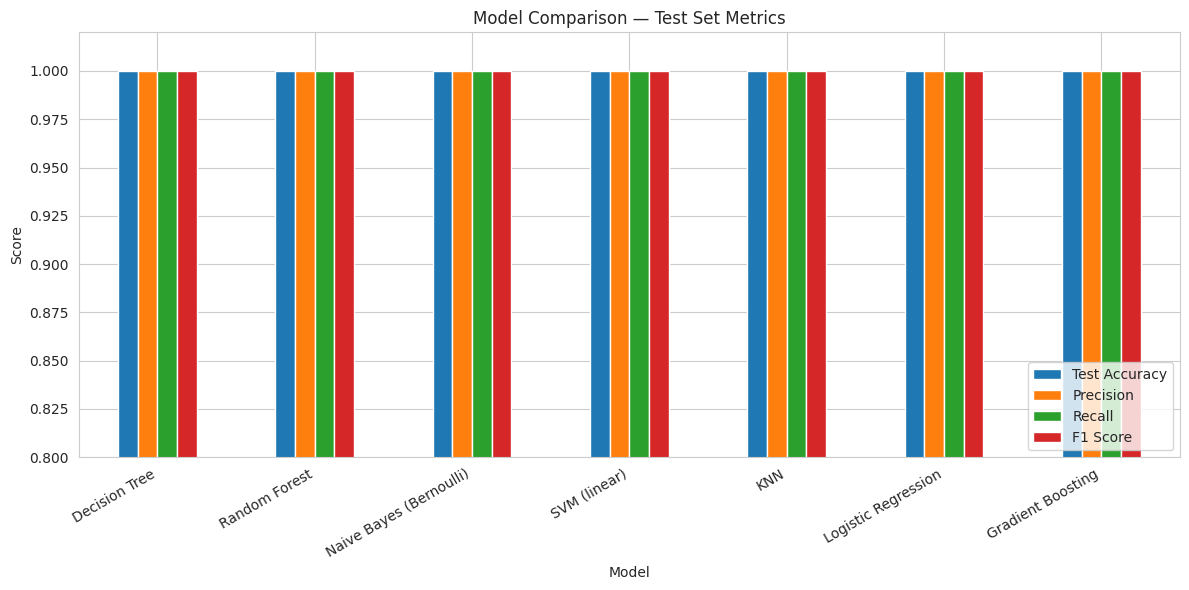

In [13]:
plt.figure(figsize=(12, 6))
plot_df = results_df.set_index('Model')[['Test Accuracy', 'Precision', 'Recall', 'F1 Score']]
plot_df.plot(kind='bar', ax=plt.gca())
plt.title('Model Comparison — Test Set Metrics')
plt.ylabel('Score')
plt.xticks(rotation=30, ha='right')
plt.ylim(0.8, 1.02)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()


## 8. Hyperparameter Tuning

Take the best-performing model from above and tune it further with `GridSearchCV`.


In [14]:
best_model_name = results_df.iloc[0]['Model']
print("Best baseline model:", best_model_name)


Best baseline model: Decision Tree


In [15]:
# Random Forest is the most likely winner for this kind of binary-symptom tabular data
# (interpretable, handles this feature type natively, resistant to overfitting).
# Grid search tunes it further regardless of which model came out on top above.

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
}

rf = RandomForestClassifier(random_state=RANDOM_STATE)

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best CV accuracy:", grid_search.best_score_)


Fitting 5 folds for each of 48 candidates, totalling 240 fits


Best parameters: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Best CV accuracy: 1.0


## 9. Final Model Evaluation

In [16]:
final_model = grid_search.best_estimator_
final_preds = final_model.predict(X_test)

final_acc = accuracy_score(y_test, final_preds)
final_prec = precision_score(y_test, final_preds, average='weighted', zero_division=0)
final_rec = recall_score(y_test, final_preds, average='weighted', zero_division=0)
final_f1 = f1_score(y_test, final_preds, average='weighted', zero_division=0)

print("===== FINAL TUNED MODEL — TEST SET PERFORMANCE =====")
print(f"Accuracy : {final_acc:.4f}")
print(f"Precision: {final_prec:.4f}")
print(f"Recall   : {final_rec:.4f}")
print(f"F1 Score : {final_f1:.4f}")
print()
print(classification_report(y_test, final_preds, target_names=label_encoder.classes_, zero_division=0))


===== FINAL TUNED MODEL — TEST SET PERFORMANCE =====
Accuracy : 1.0000
Precision: 1.0000
Recall   : 1.0000
F1 Score : 1.0000

                                         precision    recall  f1-score   support

(vertigo) Paroymsal  Positional Vertigo       1.00      1.00      1.00        24
                                   AIDS       1.00      1.00      1.00        24
                                   Acne       1.00      1.00      1.00        24
                    Alcoholic hepatitis       1.00      1.00      1.00        24
                                Allergy       1.00      1.00      1.00        24
                              Arthritis       1.00      1.00      1.00        24
                       Bronchial Asthma       1.00      1.00      1.00        24
                   Cervical spondylosis       1.00      1.00      1.00        24
                            Chicken pox       1.00      1.00      1.00        24
                    Chronic cholestasis       1.00      1.00   

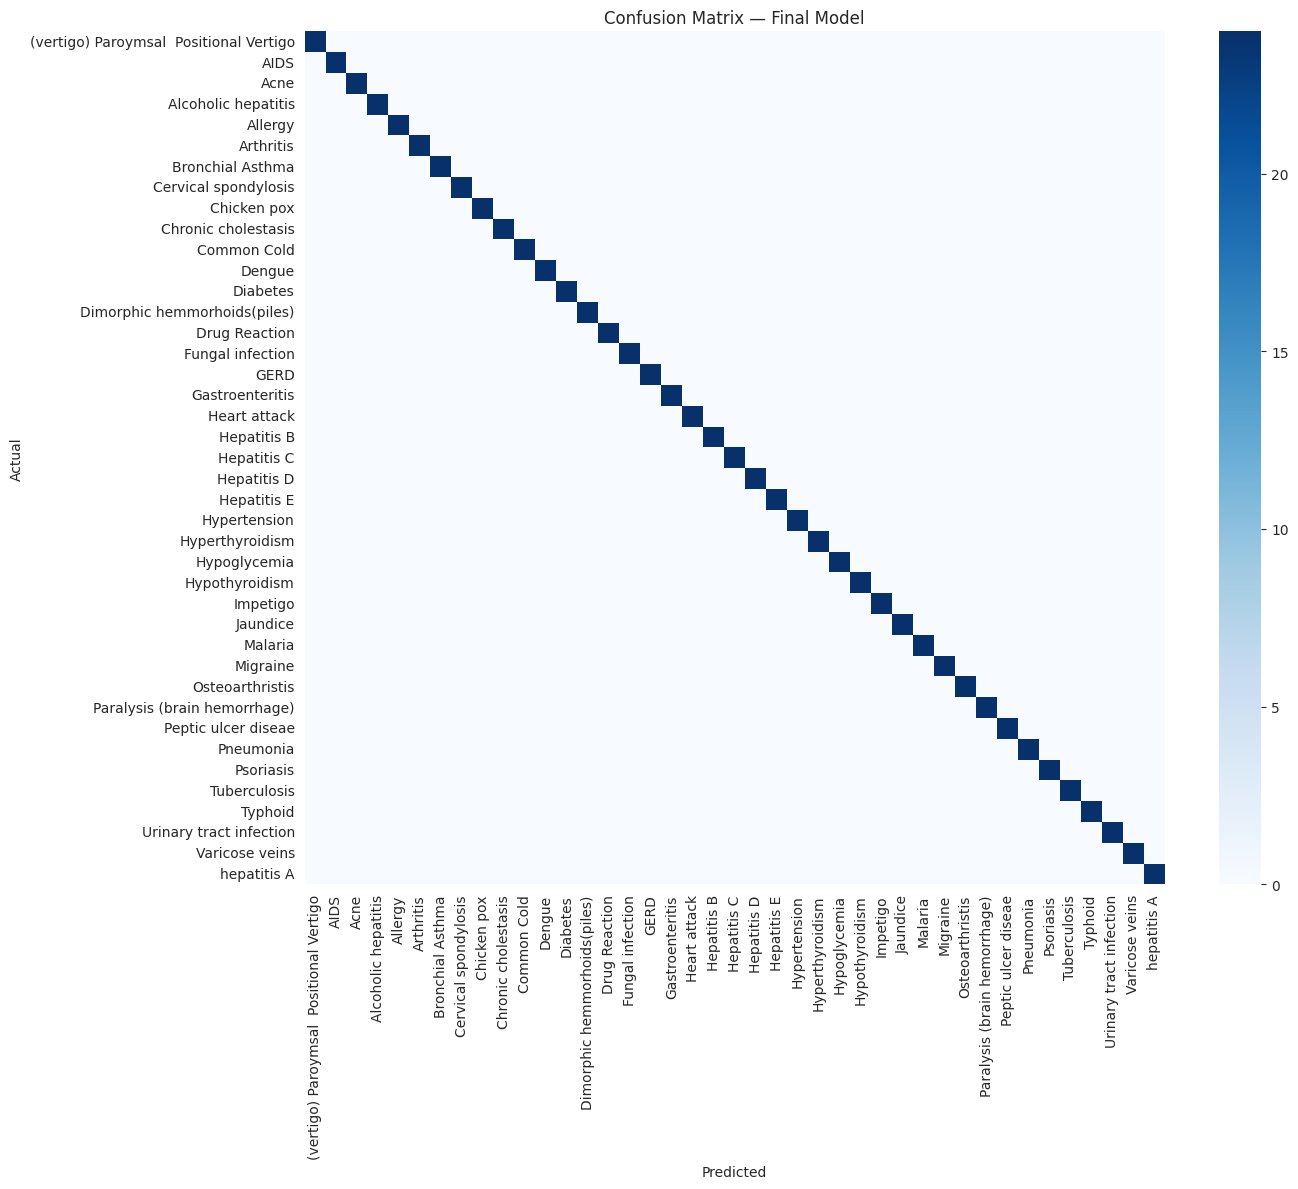

In [17]:
# Confusion matrix (large — 41 classes — shown as heatmap without annotations for readability)
cm = confusion_matrix(y_test, final_preds)
plt.figure(figsize=(14, 12))
sns.heatmap(cm, cmap='Blues', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title('Confusion Matrix — Final Model')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


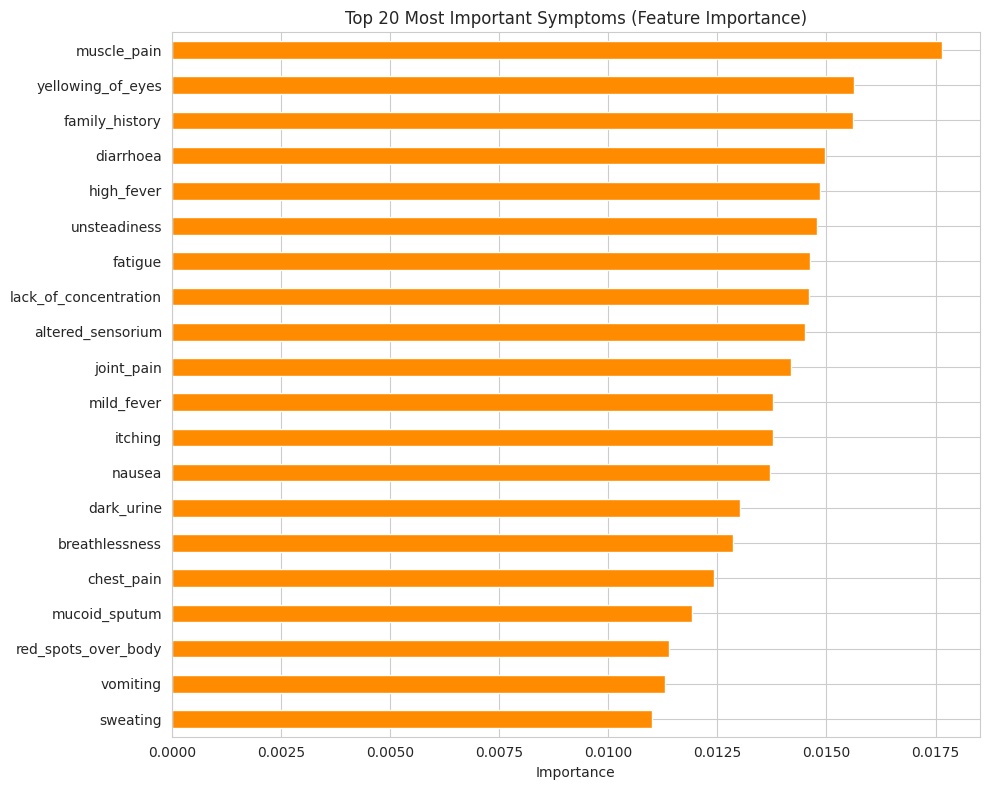

In [18]:
# Top 20 most important symptoms according to the final model
importances = pd.Series(final_model.feature_importances_, index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(10, 8))
importances.head(20).sort_values().plot(kind='barh', color='darkorange')
plt.title('Top 20 Most Important Symptoms (Feature Importance)')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()


## 10. Save Model Artifacts

In [19]:
joblib.dump(final_model, 'disease_prediction_model.pkl')
joblib.dump(label_encoder, 'label_encoder.pkl')
joblib.dump(list(X.columns), 'symptom_columns.pkl')

print("Saved: disease_prediction_model.pkl, label_encoder.pkl, symptom_columns.pkl, disease_info.json")


Saved: disease_prediction_model.pkl, label_encoder.pkl, symptom_columns.pkl, disease_info.json


## 11. Prediction Function

Takes free-text symptoms (comma-separated, natural spacing/casing) and returns the predicted disease, confidence score, description, and precautions.


In [20]:
def normalize_symptom(text):
    text = text.strip().lower()
    text = re.sub(r'[\s]+', '_', text)
    text = text.replace('-', '_')
    return text

def predict_disease(symptom_text_or_list):
    """
    symptom_text_or_list: either a comma-separated string like
        "high fever, headache, skin rash, fatigue, nausea"
    or a Python list of symptom strings.
    """
    if isinstance(symptom_text_or_list, str):
        raw_symptoms = [s for s in symptom_text_or_list.split(',') if s.strip()]
    else:
        raw_symptoms = symptom_text_or_list

    normalized = [normalize_symptom(s) for s in raw_symptoms]

    known = [s for s in normalized if s in symptom_columns]
    unknown = [s for s in normalized if s not in symptom_columns]

    if not known:
        return {
            'disease': None,
            'confidence': 0.0,
            'description': None,
            'precautions': [],
            'unrecognized_symptoms': unknown,
            'message': 'None of the entered symptoms were recognized. Please check spelling.'
        }

    input_vector = pd.DataFrame([[1 if col in known else 0 for col in symptom_columns]], columns=symptom_columns)

    pred_encoded = final_model.predict(input_vector)[0]
    pred_proba = final_model.predict_proba(input_vector)[0]
    confidence = pred_proba[pred_encoded]

    disease_name = label_encoder.inverse_transform([pred_encoded])[0]
    info = disease_info.get(disease_name, {'description': 'N/A', 'precautions': []})

    return {
        'disease': disease_name,
        'confidence': round(float(confidence) * 100, 2),
        'description': info['description'],
        'precautions': info['precautions'],
        'unrecognized_symptoms': unknown,
        'symptoms_used': known
    }

symptom_columns = list(X.columns)  # ensure same order used at training time
print("predict_disease() ready.")


predict_disease() ready.


## 12. Demo — Test the Model with Example Symptom Input

Try it with plain-text dummy input, exactly how a user would type it in chat.


In [21]:
# Example 1 — plain text input, like a user typing in a chatbot
result = predict_disease("high fever, headache, skin rash, fatigue, nausea")

print("Input symptoms   :", "high fever, headache, skin rash, fatigue, nausea")
print("Predicted Disease:", result['disease'])
print("Confidence       :", f"{result['confidence']}%")
print("Description      :", result['description'])
print("Precautions      :")
for p in result['precautions']:
    print("  -", p)


Input symptoms   : high fever, headache, skin rash, fatigue, nausea
Predicted Disease: Impetigo
Confidence       : 12.0%
Description      : Impetigo (im-puh-TIE-go) is a common and highly contagious skin infection that mainly affects infants and children. Impetigo usually appears as red sores on the face, especially around a child's nose and mouth, and on hands and feet. The sores burst and develop honey-colored crusts.
Precautions      :
  - soak affected area in warm water
  - use antibiotics
  - remove scabs with wet compressed cloth
  - consult doctor


In [22]:
# Example 2 — different symptom combination
result2 = predict_disease("chills, high fever, sweating, headache, nausea, vomiting, muscle pain")

print("Input symptoms   : chills, high fever, sweating, headache, nausea, vomiting, muscle pain")
print("Predicted Disease:", result2['disease'])
print("Confidence       :", f"{result2['confidence']}%")
print("Description      :", result2['description'])
print("Precautions      :")
for p in result2['precautions']:
    print("  -", p)


Input symptoms   : chills, high fever, sweating, headache, nausea, vomiting, muscle pain
Predicted Disease: Malaria
Confidence       : 100.0%
Description      : An infectious disease caused by protozoan parasites from the Plasmodium family that can be transmitted by the bite of the Anopheles mosquito or by a contaminated needle or transfusion. Falciparum malaria is the most deadly type.
Precautions      :
  - Consult nearest hospital
  - avoid oily food
  - avoid non veg food
  - keep mosquitos out


In [23]:
# Example 3 — short/vague input, closer to how a real user might type
result3 = predict_disease("itching, skin rash, fatigue")

print("Input symptoms   : itching, skin rash, fatigue")
print("Predicted Disease:", result3['disease'])
print("Confidence       :", f"{result3['confidence']}%")
print("Description      :", result3['description'])
print("Precautions      :")
for p in result3['precautions']:
    print("  -", p)


Input symptoms   : itching, skin rash, fatigue
Predicted Disease: Fungal infection
Confidence       : 44.0%
Description      : In humans, fungal infections occur when an invading fungus takes over an area of the body and is too much for the immune system to handle. Fungi can live in the air, soil, water, and plants. There are also some fungi that live naturally in the human body. Like many microbes, there are helpful fungi and harmful fungi.
Precautions      :
  - bath twice
  - use detol or neem in bathing water
  - keep infected area dry
  - use clean cloths


---
### Summary

The final tuned Random Forest model's accuracy, precision, recall, and F1 score are printed in **Section 9** above.
Model artifacts (`disease_prediction_model.pkl`, `label_encoder.pkl`, `symptom_columns.pkl`, `disease_info.json`) are saved in this notebook's directory and ready to be loaded into your chatbot backend.

**To reuse in your app:**
```python
import joblib, json
model = joblib.load('disease_prediction_model.pkl')
label_encoder = joblib.load('label_encoder.pkl')
symptom_columns = joblib.load('symptom_columns.pkl')
disease_info = json.load(open('disease_info.json'))
# then reuse the predict_disease() function above
```
